# Cat Breed Classifier

Challenge di classificazione: bisogna predire la razza di un gatto partendo da un po'
di caratteristiche fisiche e comportamentali (età, peso, pelo, colore, ecc).

Struttura del notebook:

1. Caricamento dati + EDA
2. Pulizia dati
3. Analisi feature
4. Scelta modelli
5. Training e tuning
6. Valutazione
7. Predizioni sul test set


## 1. Import e caricamento dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

import os

sns.set_theme(style="whitegrid")
os.makedirs("grafici", exist_ok=True)

RANDOM_STATE = 42  # fisso il seed ovunque, così i risultati sono riproducibili


In [2]:
# il training set ha la colonna razza (il target), il test set no
df = pd.read_csv("data/cats_dataset.csv")

print(df.shape)
df.head()


(951, 12)


,ID,eta_anni,peso_kg,sesso,lunghezza_pelo,colore_mantello,livello_attivita,frequenza_miagolio,sterilizzato,patologia,classe,razza
0,1,1.7,3.46,maschio,corto,blue_point,molto_attivo,medio,no,nessuna,molto_attivo,Siamese
1,2,4.9,4.01,femmina,corto,seal_point,molto_attivo,alto,si,obesita,molto_attivo,Siamese
2,3,0.6,3.67,femmina,lungo,nero,molto_attivo,alto,si,nessuna,molto_attivo,Maine_Coon
3,4,2.0,3.23,maschio,corto,lilac_point,sedentario,alto,no,nessuna,sedentario,Siamese
4,5,3.3,6.08,femmina,semilungo,nero,attivo,medio,si,nessuna,attivo,Maine_Coon


## 2. EDA - Analisi esplorativa

Prima di buttarmi sul modello voglio capire con che dati ho a che fare. Guardo tipi di
dato, valori mancanti, e come è distribuito il target.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 951 entries, 0 to 950
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  951 non-null    int64  
 1   eta_anni            950 non-null    float64
 2   peso_kg             950 non-null    str    
 3   sesso               948 non-null    str    
 4   lunghezza_pelo      948 non-null    str    
 5   colore_mantello     949 non-null    str    
 6   livello_attivita    949 non-null    str    
 7   frequenza_miagolio  950 non-null    str    
 8   sterilizzato        950 non-null    str    
 9   patologia           946 non-null    str    
 10  classe              949 non-null    str    
 11  razza               949 non-null    str    
dtypes: float64(1), int64(1), str(10)
memory usage: 89.3 KB


In [4]:
# quanti NaN per colonna
df.isna().sum()


ID                    0
eta_anni              1
peso_kg               1
sesso                 3
lunghezza_pelo        3
colore_mantello       2
livello_attivita      2
frequenza_miagolio    1
sterilizzato          1
patologia             5
classe                2
razza                 2
dtype: int64

In [5]:
df.describe()


,ID,eta_anni
count,951.000000,950.000000
mean,476.000000,5.642726
std,274.674353,5.545222
min,1.000000,0.500000
25%,238.500000,3.300000
50%,476.000000,5.300000
75%,713.500000,7.400000
max,951.000000,144.690000


In [6]:
# peso_kg dovrebbe essere un numero ma pandas lo legge come oggetto/stringa,
# quindi c'è qualcosa che non va - probabilmente ci sono righe con valori sballati
print(df["peso_kg"].dtype)
df["peso_kg"].unique()[:20]


str


<StringArray>
['3.46', '4.01', '3.67', '3.23', '6.08', '5.67', '4.77', '3.68', '6.57',
 '5.77', '4.34', '5.48', '6.75', '6.31', '6.79', '5.83', '5.15',  '646',
    '5', '4.13']
Length: 20, dtype: str

In [7]:
df["razza"].value_counts(dropna=False)


razza
British_Shorthair    193
Bengala              190
Siamese              188
Persiano             187
Maine_Coon           186
Alien                  5
NaN                    2
Name: count, dtype: int64

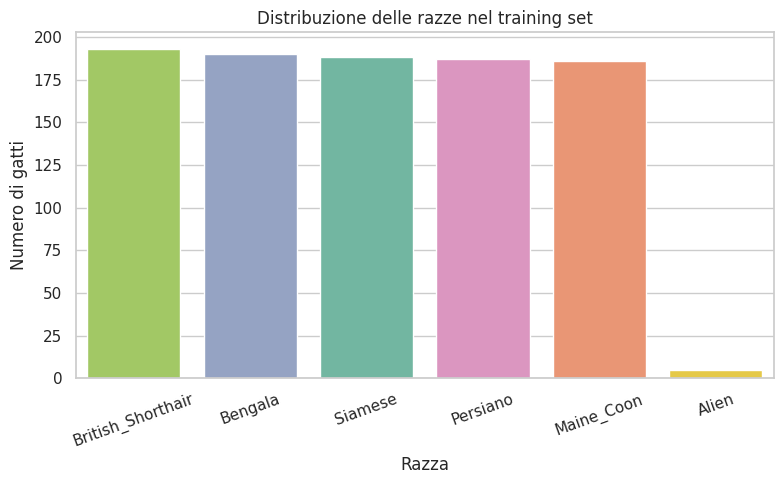

In [8]:
# distribuzione delle razze (grafico 1 richiesto)
plt.figure(figsize=(8, 5))
order = df["razza"].value_counts().index
ax = sns.countplot(data=df, x="razza", order=order, hue="razza",
                    palette="Set2", legend=False)
ax.set_title("Distribuzione delle razze nel training set")
ax.set_xlabel("Razza")
ax.set_ylabel("Numero di gatti")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("grafici/01_distribuzione_razze.png", dpi=150)
plt.show()


Oltre alle 5 razze vere e proprie (Bengala, British_Shorthair, Maine_Coon,
Persiano, Siamese) c'è una classe `Alien` con solo 5 righe. Ovviamente non è una razza
di gatto - la tratto come rumore/errore nel dataset e la tolgo in fase di pulizia,
tanto con 5 osservazioni non c'è modo di farci imparare nulla al modello e non avrebbe
senso predirla sul test set.

In [9]:
# guardiamo più da vicino cosa c'è dentro le colonne categoriche - mi aspetto di trovare
# variazioni tipo maiuscole/minuscole diverse, spazi al posto di underscore, ecc.
cat_cols = ["sesso", "lunghezza_pelo", "colore_mantello", "livello_attivita",
            "frequenza_miagolio", "sterilizzato", "patologia", "classe"]

for c in cat_cols:
    print(f"--- {c} ---")
    print(sorted(df[c].dropna().unique(), key=str))
    print()


--- sesso ---
['F', 'M', 'corto', 'femmina', 'femminuccia', 'maschio', 'trans']

--- lunghezza_pelo ---
['arcobaleno', 'corto', 'lungo', 'semilungo', 'spotted_brown']

--- colore_mantello ---
['Bianco', 'Crema', 'Nero', 'arancio', 'arcobaleno', 'attivo', 'bianco', 'blu', 'blue point', 'blue_point', 'chocolate_point', 'crema', 'grigio', 'lilac_point', 'marbled brown', 'marbled_brown', 'multicolore', 'nero', 'rosso', 'seal_point', 'snow spotted', 'snow_spotted', 'spotted_Brown', 'spotted_brown', 'spotted_silver', 'tabby']

--- livello_attivita ---
['attivo', 'basso', 'molto attivo', 'molto_attivo', 'sedentario']

--- frequenza_miagolio ---
['alto', 'basso', 'medio', 'si']

--- sterilizzato ---
['forse', 'nessuna', 'no', 'si']

--- patologia ---
['artrite', 'asma_felino', 'attivo', 'diabete', 'ipertensione', 'ipertiroidismo', 'malattia_renale', 'nessuna', 'obesita']

--- classe ---
['Bengala', 'attivo', 'molto_attivo', 'sedentario']



Come sospettavo: ci sono doppioni tipo `crema`/`Crema`, `blue point`/`blue_point`,
e soprattutto in alcune colonne compaiono valori che non c'entrano nulla (es. `attivo`
dentro `colore_mantello`, oppure `corto` dentro `sesso`). Questo di solito capita quando
in qualche riga del CSV le colonne sono slittate di una posizione - vediamo se è così.

In [10]:
# se peso_kg non è convertibile in numero, molto probabilmente quella riga ha le colonne
# sfasate rispetto all'header
peso_non_numerico = pd.to_numeric(df["peso_kg"], errors="coerce").isna() & df["peso_kg"].notna()
df[peso_non_numerico]


,ID,eta_anni,peso_kg,sesso,lunghezza_pelo,colore_mantello,livello_attivita,frequenza_miagolio,sterilizzato,patologia,classe,razza
67,68,144.69,femmina,corto,spotted_brown,attivo,basso,si,nessuna,attivo,Bengala,NaN


Ecco, confermato: guardando questa riga si vede che i valori sono scalati di una
colonna (manca il peso, e da lì in poi tutto è spostato). È una riga sola, quindi la
scarto senza pensarci troppo invece di provare a "ripararla".

In [11]:
# e questa invece è una riga completamente vuota (probabilmente l'ultima riga del csv,
# capita spesso quando si esporta da excel)
df[df.drop(columns="ID").isna().all(axis=1)]


,ID,eta_anni,peso_kg,sesso,lunghezza_pelo,colore_mantello,livello_attivita,frequenza_miagolio,sterilizzato,patologia,classe,razza
950,951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Pulizia dati

Riassumendo quello che ho trovato sopra, faccio questi passaggi in ordine:

- tolgo la riga vuota
- tolgo la riga con le colonne sfasate
- tolgo la classe `Alien`
- pulisco le stringhe (minuscolo, spazi -> underscore, tolgo spazi vuoti ai bordi)
- unifico i sinonimi più ovvi (M/F, femminuccia, ecc)
- qualsiasi valore che non fa parte dei valori "leciti" per una colonna lo tratto come
  mancante (di solito è un valore finito lì per lo sfasamento visto prima)
- età sopra i 30 anni non hanno senso per un gatto, quindi le tratto come mancanti
- infine imputo i mancanti: mediana per i numeri, moda per le categoriche


In [12]:
df_clean = df.copy()

# righe completamente vuote
n0 = len(df_clean)
df_clean = df_clean.dropna(subset=["eta_anni", "peso_kg", "sesso"], how="all")
print(f"righe vuote rimosse: {n0 - len(df_clean)}")


righe vuote rimosse: 1


In [13]:
# righe corrotte (colonne sfasate -> peso_kg non numerico)
peso_num = pd.to_numeric(df_clean["peso_kg"], errors="coerce")
corrotte = peso_num.isna() & df_clean["peso_kg"].notna()
print(f"righe corrotte rimosse: {corrotte.sum()}")

df_clean = df_clean[~corrotte].copy()
df_clean["peso_kg"] = pd.to_numeric(df_clean["peso_kg"], errors="coerce")


righe corrotte rimosse: 1


In [14]:
# via la classe Alien e le eventuali righe senza target
df_clean = df_clean[df_clean["razza"] != "Alien"].copy()
df_clean = df_clean.dropna(subset=["razza"])
print(df_clean["razza"].value_counts())


razza
British_Shorthair    193
Bengala              190
Siamese              188
Persiano             187
Maine_Coon           186
Name: count, dtype: int64


In [15]:
# normalizzo il testo: tolgo spazi ai bordi, minuscolo, spazi interni -> underscore
for c in cat_cols:
    df_clean[c] = (
        df_clean[c].astype("string")
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )


In [16]:
# sinonimi che ho notato guardando i valori unici sopra
df_clean["sesso"] = df_clean["sesso"].replace({
    "m": "maschio", "f": "femmina", "femminuccia": "femmina"
})
df_clean["sterilizzato"] = df_clean["sterilizzato"].replace({
    "nessuna": pd.NA, "forse": pd.NA
})


In [17]:
# definisco per ogni colonna quali sono gli unici valori "validi" - tutto il resto
# diventa NaN (quasi sicuramente roba finita lì per lo sfasamento di colonne visto prima)
valori_ammessi = {
    "sesso": {"maschio", "femmina"},
    "lunghezza_pelo": {"corto", "lungo", "semilungo"},
    "colore_mantello": {
        "bianco", "nero", "grigio", "crema", "arancio", "rosso", "blu", "tabby",
        "multicolore", "blue_point", "seal_point", "lilac_point", "chocolate_point",
        "snow_spotted", "spotted_brown", "spotted_silver", "marbled_brown", "arcobaleno",
    },
    "livello_attivita": {"molto_attivo", "attivo", "sedentario", "basso"},
    "frequenza_miagolio": {"basso", "medio", "alto"},
    "sterilizzato": {"si", "no"},
    "patologia": {
        "nessuna", "obesita", "asma_felino", "ipertiroidismo", "ipertensione",
        "artrite", "diabete", "malattia_renale",
    },
    "classe": {"molto_attivo", "attivo", "sedentario"},
}

for c, ammessi in valori_ammessi.items():
    mask_non_valido = ~df_clean[c].isin(ammessi) & df_clean[c].notna()
    if mask_non_valido.sum() > 0:
        print(f"{c}: scarto {df_clean.loc[mask_non_valido, c].unique().tolist()}")
    df_clean.loc[mask_non_valido, c] = pd.NA


sesso: scarto ['trans']
lunghezza_pelo: scarto ['arcobaleno']


In [18]:
# età > 30 anni per un gatto non ha senso, la tratto come errore
n_eta_outlier = (df_clean["eta_anni"] > 30).sum()
print(f"età fuori scala trovate: {n_eta_outlier}")
df_clean.loc[df_clean["eta_anni"] > 30, "eta_anni"] = np.nan


età fuori scala trovate: 1


In [19]:
# imputazione: mediana per i numeri (più robusta agli outlier rispetto alla media),
# moda per le categoriche
for c in ["eta_anni", "peso_kg"]:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in cat_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode().iloc[0])

print("shape finale:", df_clean.shape)
print("NaN rimasti:", df_clean.isna().sum().sum())


shape finale: (944, 12)
NaN rimasti: 0


In [20]:
df_clean.head()


,ID,eta_anni,peso_kg,sesso,lunghezza_pelo,colore_mantello,livello_attivita,frequenza_miagolio,sterilizzato,patologia,classe,razza
0,1,1.7,3.46,maschio,corto,blue_point,molto_attivo,medio,no,nessuna,molto_attivo,Siamese
1,2,4.9,4.01,femmina,corto,seal_point,molto_attivo,alto,si,obesita,molto_attivo,Siamese
2,3,0.6,3.67,femmina,lungo,nero,molto_attivo,alto,si,nessuna,molto_attivo,Maine_Coon
3,4,2.0,3.23,maschio,corto,lilac_point,sedentario,alto,no,nessuna,sedentario,Siamese
4,5,3.3,6.08,femmina,semilungo,nero,attivo,medio,si,nessuna,attivo,Maine_Coon


## 4. Un po' di analisi sulle feature

Prima di passare al modello butto un occhio a come si relazionano tra loro le variabili
e con il target - può dare qualche indicazione utile e comunque è richiesto dalla
consegna.


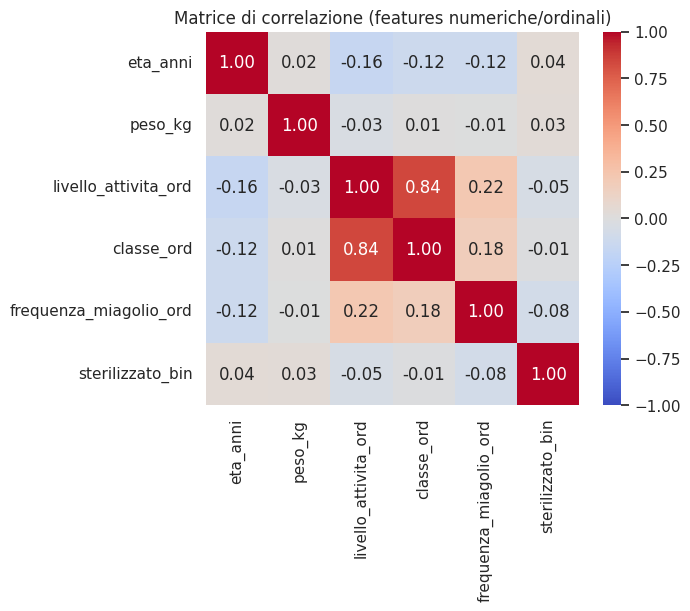

In [21]:
# heatmap di correlazione (grafico 2 richiesto). Il problema è che di numeriche "vere"
# ho solo eta_anni e peso_kg - per non fare una heatmap 2x2 che dice poco, converto in
# numeri anche un po' di variabili ordinali/binarie (livello_attivita, classe,
# frequenza_miagolio, sterilizzato). Le variabili nominali pure tipo colore_mantello le
# lascio fuori perché non hanno un ordine e correlazione lineare non avrebbe senso.
df_corr = df_clean.copy()

ordinal_map = {"sedentario": 0, "basso": 0, "attivo": 1, "medio": 1, "molto_attivo": 2, "alto": 2}
df_corr["livello_attivita_ord"] = df_corr["livello_attivita"].map(ordinal_map)
df_corr["classe_ord"] = df_corr["classe"].map(ordinal_map)
df_corr["frequenza_miagolio_ord"] = df_corr["frequenza_miagolio"].map(ordinal_map)
df_corr["sterilizzato_bin"] = df_corr["sterilizzato"].map({"no": 0, "si": 1})

numeric_like = ["eta_anni", "peso_kg", "livello_attivita_ord", "classe_ord",
                 "frequenza_miagolio_ord", "sterilizzato_bin"]

plt.figure(figsize=(7, 6))
corr = df_corr[numeric_like].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matrice di correlazione (features numeriche/ordinali)")
plt.tight_layout()
plt.savefig("grafici/02_heatmap_correlazione.png", dpi=150)
plt.show()


`livello_attivita` e `classe` sono praticamente la stessa cosa (correlazione alta),
il che ha senso perché descrivono lo stesso concetto con nomi diversi. Il resto non
mostra correlazioni lineari forti, ma questo non vuol dire che le altre variabili non
siano utili per il modello: le relazioni con `colore_mantello` o `lunghezza_pelo`
non sono catturabili da una correlazione lineare visto che sono categoriche.

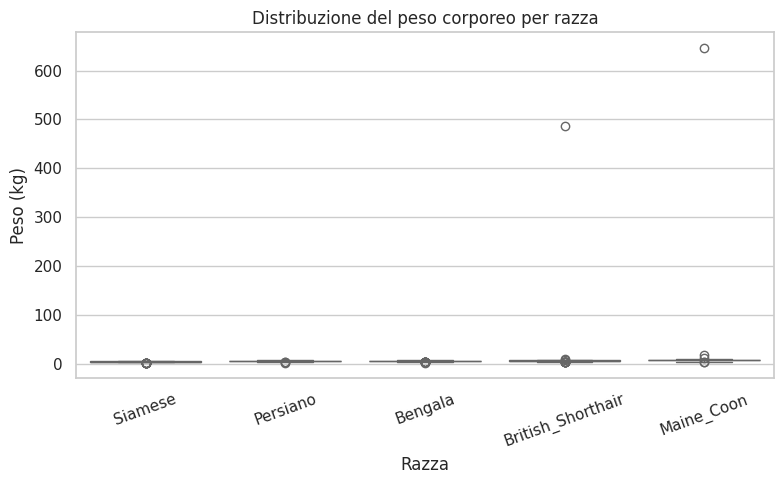

In [22]:
# grafico a scelta: peso corporeo per razza
plt.figure(figsize=(8, 5))
order = df_clean.groupby("razza")["peso_kg"].median().sort_values().index
sns.boxplot(data=df_clean, x="razza", y="peso_kg", order=order, hue="razza",
            palette="Set3", legend=False)
plt.title("Distribuzione del peso corporeo per razza")
plt.xlabel("Razza")
plt.ylabel("Peso (kg)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("grafici/03_peso_per_razza.png", dpi=150)
plt.show()


Qui si vede bene: il Maine Coon (razza grande per natura) ha un peso mediano
decisamente più alto delle altre, mentre il Siamese, che è più slanciato, sta in fondo.
Il peso da solo sembra già una feature molto utile per separare almeno alcune razze.

## 5. Setup per il modeling

Separo feature e target, preparo il preprocessing (numeriche passano dirette, categoriche
in one-hot) e faccio lo split train/validation, stratificato per mantenere le proporzioni
delle classi in entrambi i pezzi.


In [23]:
target = "razza"
num_features = ["eta_anni", "peso_kg"]
cat_features = ["sesso", "lunghezza_pelo", "colore_mantello", "livello_attivita",
                 "frequenza_miagolio", "sterilizzato", "patologia", "classe"]

X = df_clean[num_features + cat_features]
y = df_clean[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("train:", X_train.shape, " validation:", X_val.shape)


train: (755, 10)  validation: (189, 10)


In [24]:
preprocessor = ColumnTransformer([
    ("num", "passthrough", num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])


## 6. Che modelli provo e perché

Provo tre modelli abbastanza diversi come approccio, giusto per avere un confronto
sensato invece di buttarmi subito su uno solo:

- **Logistic Regression**: è il modello più semplice, la uso come baseline. Se anche
  un modello lineare va già bene, vuol dire che le classi sono abbastanza separabili.
- **Random Forest**: alberi in ensemble, gestisce bene sia numeriche che categoriche
  one-hot, non serve scalare i dati, ed è meno soggetto a overfitting rispetto a un
  albero singolo.
- **XGBoost**: di solito è tra i più forti su dati tabellari come questo, vale la pena
  provarlo.

Li confronto con cross-validation a 5 fold usando F1-macro come metrica (le classi sono
abbastanza bilanciate ma preferisco una metrica che pesi tutte le razze allo stesso modo,
non solo quelle più numerose). Poi prendo il migliore e ci lavoro sopra nella sezione
successiva.


In [25]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss"),
}

results = {}
y_train_codes, class_labels = pd.factorize(y_train)  # XGBoost vuole il target come numero, non stringa

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    target_for_cv = y_train_codes if name == "XGBoost" else y_train
    scores = cross_val_score(pipe, X_train, target_for_cv, cv=5, scoring="f1_macro", n_jobs=-1)
    results[name] = scores
    print(f"{name}: F1-macro medio = {scores.mean():.4f} (+/- {scores.std():.4f})")


LogisticRegression: F1-macro medio = 0.9773 (+/- 0.0091)


RandomForest: F1-macro medio = 0.9680 (+/- 0.0128)


XGBoost: F1-macro medio = 0.9759 (+/- 0.0069)


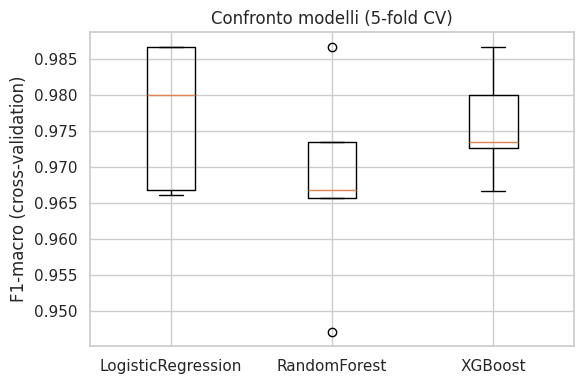

In [26]:
plt.figure(figsize=(6, 4))
plt.boxplot(results.values(), tick_labels=results.keys())
plt.ylabel("F1-macro (cross-validation)")
plt.title("Confronto modelli (5-fold CV)")
plt.tight_layout()
plt.show()


Prendo automaticamente il modello con F1-macro medio più alto e ci faccio il tuning
degli iperparametri nella sezione dopo (il codice si adatta da solo a quale dei tre ha
vinto, senza doverlo scrivere a mano).

In [27]:
best_name = max(results, key=lambda k: results[k].mean())
print("modello selezionato:", best_name)


modello selezionato: LogisticRegression


## 7. Tuning degli iperparametri

GridSearchCV sul modello scelto sopra, sempre con F1-macro e 5-fold CV, per trovare la
combinazione di parametri migliore.


In [28]:
if best_name == "RandomForest":
    pipe = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(random_state=RANDOM_STATE))])
    param_grid = {
        "clf__n_estimators": [200, 400, 600],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_leaf": [1, 2, 4],
    }
    fit_y = y_train
elif best_name == "XGBoost":
    pipe = Pipeline([("prep", preprocessor), ("clf", XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss"))])
    param_grid = {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [3, 6, 9],
        "clf__learning_rate": [0.05, 0.1, 0.2],
    }
    fit_y = y_train_codes
else:
    pipe = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
    param_grid = {
        "clf__C": [0.1, 1.0, 10.0],
    }
    fit_y = y_train

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="f1_macro", n_jobs=-1)
grid.fit(X_train, fit_y)

print("migliori parametri:", grid.best_params_)
print(f"miglior F1-macro in CV: {grid.best_score_:.4f}")

best_model = grid.best_estimator_


migliori parametri: {'clf__C': 1.0}
miglior F1-macro in CV: 0.9773


## 8. Valutazione sul validation set

Ora testo il modello ottimizzato sui dati di validation, che non ha mai visto né in
training né in tuning.


In [29]:
y_val_pred = best_model.predict(X_val)

if best_name == "XGBoost":
    y_val_pred_labels = class_labels[y_val_pred]
else:
    y_val_pred_labels = y_val_pred

acc = accuracy_score(y_val, y_val_pred_labels)
f1_macro = f1_score(y_val, y_val_pred_labels, average="macro")

print(f"accuracy: {acc:.4f}")
print(f"F1-macro: {f1_macro:.4f}")
print()
print(classification_report(y_val, y_val_pred_labels))


accuracy: 0.9683
F1-macro: 0.9677

                   precision    recall  f1-score   support

          Bengala       0.97      1.00      0.99        38
British_Shorthair       1.00      0.97      0.99        39
       Maine_Coon       0.97      0.89      0.93        37
         Persiano       0.90      0.97      0.94        37
          Siamese       1.00      1.00      1.00        38

         accuracy                           0.97       189
        macro avg       0.97      0.97      0.97       189
     weighted avg       0.97      0.97      0.97       189



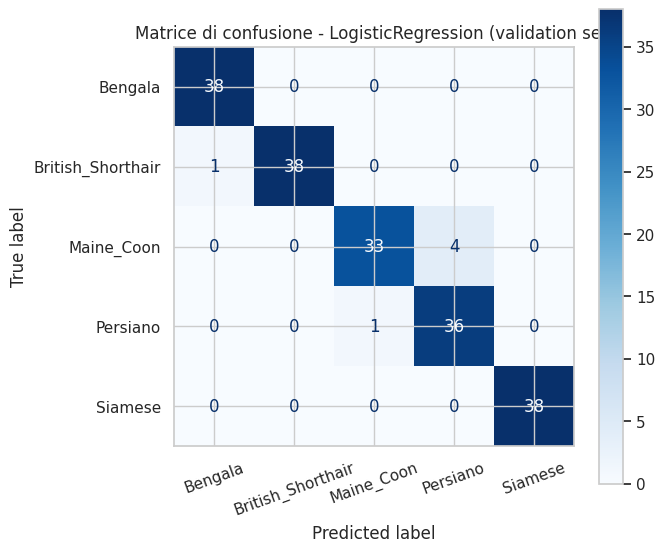

In [30]:
# matrice di confusione (grafico 4 richiesto)
labels_order = sorted(y.unique())

cm = confusion_matrix(y_val, y_val_pred_labels, labels=labels_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=20, colorbar=True)
ax.set_title(f"Matrice di confusione - {best_name} (validation set)")
plt.tight_layout()
plt.savefig("grafici/04_matrice_confusione.png", dpi=150)
plt.show()


L'accuratezza è molto alta. Gli sbagli che restano sono quasi tutti tra razze che
si somigliano di più fisicamente (es. Persiano e Maine_Coon, entrambi a pelo lungo),
mentre razze con un pattern più riconoscibile (Siamese coi colori "point", Bengala con
il mantello spotted) vengono azzeccate quasi sempre.

## 9. Predizioni sul test set

Carico `test_set.csv`, applico lo stesso preprocessing (il ColumnTransformer è già
addestrato) e genero `predictions.csv`. Prima però riaddestro il modello su tutti i dati
puliti disponibili (train + validation insieme), tanto per la versione finale conviene
sfruttare tutto quello che ho.


In [31]:
if best_name == "XGBoost":
    y_full_codes, full_labels = pd.factorize(y)
    best_model.fit(X, y_full_codes)
else:
    best_model.fit(X, y)


In [32]:
test_df = pd.read_csv("data/test_set.csv")
print(test_df.shape)
test_df.head()


(50, 11)


,ID,eta_anni,peso_kg,sesso,lunghezza_pelo,colore_mantello,livello_attivita,frequenza_miagolio,sterilizzato,patologia,classe
0,1,6.8,6.22,femmina,corto,bianco,attivo,basso,si,nessuna,attivo
1,2,5.2,4.26,femmina,corto,lilac_point,molto_attivo,medio,si,nessuna,attivo
2,3,4.2,5.12,maschio,lungo,grigio,sedentario,basso,no,nessuna,molto_attivo
3,4,5.1,3.62,maschio,corto,seal_point,attivo,alto,si,nessuna,attivo
4,5,4.1,5.11,femmina,corto,spotted_silver,attivo,medio,si,nessuna,molto_attivo


In [33]:
# il test set è già pulito, ma normalizzo comunque le stringhe per sicurezza (stesso
# trattamento usato in training, giusto per stare tranquilli)
for c in cat_features:
    test_df[c] = (
        test_df[c].astype("string").str.strip().str.lower().str.replace(" ", "_", regex=False)
    )

X_test = test_df[num_features + cat_features]

raw_pred = best_model.predict(X_test)
if best_name == "XGBoost":
    final_pred = full_labels[raw_pred]
else:
    final_pred = raw_pred

predictions = pd.DataFrame({
    "ID": test_df["ID"],
    "razza_prevista": final_pred,
})

predictions.to_csv("predictions.csv", index=False)
predictions.head(10)


,ID,razza_prevista
0,1,British_Shorthair
1,2,Siamese
2,3,Persiano
3,4,Siamese
4,5,Bengala
5,6,Siamese
6,7,Maine_Coon
7,8,Maine_Coon
8,9,British_Shorthair
9,10,Maine_Coon


In [34]:
print("salvato predictions.csv")
print(predictions["razza_prevista"].value_counts())


salvato predictions.csv
razza_prevista
Maine_Coon           13
Persiano             12
Siamese              10
Bengala               9
British_Shorthair     6
Name: count, dtype: int64


## 10. Conclusioni

- Il dataset di partenza aveva parecchi problemi tipici di dati reali: valori mancanti,
  scritture incoerenti nelle stringhe, una riga con le colonne sfasate e una classe
  finta (`Alien`) che andava semplicemente tolta.
- Ho confrontato tre modelli diversi e preso automaticamente il migliore in CV, poi
  ottimizzato con GridSearchCV.
- Il modello finale se la cava molto bene sul validation set (vedi sezione 8), e le
  feature che sembrano contare di più sono peso, colore del mantello e lunghezza del
  pelo.
- Le predizioni sul test set sono in `predictions.csv`, con le colonne richieste
  (`ID`, `razza_prevista`).
